# Stronger Decoder VAE — CS424 Assignment 2 (Architecture 2)

**Architecture:** Architecture 1 encoder + significantly stronger decoder to fix missing detail.

Key changes from Architecture 1:
- **Decoder is now wider than encoder** — starts at 80 ch @ 4×4, expands to 128 ch @ 8×16, vs encoder's 64 ch at those scales
- **Two ResBlocks per decoder upsampling stage** (was one) — more capacity at every resolution
- **Upsample(nearest) + Conv(3×3)** replaces all ConvTranspose(4×4) — eliminates checkerboard artefacts
- Encoder unchanged from Architecture 1 (already well-designed)
- KL warmup, AdamW, CosineAnnealingLR all retained


In [4]:
import torch
from datetime import datetime
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import torch_fidelity
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

# Ensure working directory is the project root (one level up from Iteration2/)
if os.path.basename(os.getcwd()) == "Iteration11":
    os.chdir("..")
print(f"Working directory: {os.getcwd()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = DEVICE  # alias used in training loop / evaluation cells
print(f"Device: {DEVICE}")

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to: {seed}")


set_seed(42)


Working directory: c:\Users\josep\Y3S2\CS424\Assgin2\cs-424-assign-2-friday
Device: cuda
Random seed set to: 42


## Configuration

All key hyperparameters in one place — change values here to run ablations without touching the rest of the notebook.

In [5]:
CFG = {
    "experiment_name":   "stronger_decoder_vae_v6_attn_screening",
    "seed":              42,
    "image_size":        64,
    "batch_size":        32,
    "latent_dim":        32,
    "base_channels":     64,
    "dec_start_ch":      128,       # was 80
    "num_epochs":        250,        # changed from 150
    "lr":                1e-3,
    "weight_decay":      1e-4,
    "kl_warmup_epochs":  8,         # changed from 10
    "beta_max":          1.0,
    "recon_loss_type":   "l1",
    "grad_clip":         1.0,
    "data_root":         "./VAE_generation",
    "real_images_dir":   "./VAE_generation/train",
    "save_dir_images":   "./Iteration11/generated_images/",       # changed from Iteration3
    "checkpoint_dir":    "./Iteration11/checkpoints/stronger_decoder/",  # changed from Iteration3
    "num_workers":       2,
}

os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
os.makedirs(CFG["save_dir_images"], exist_ok=True)
print("Config loaded:", CFG)


Config loaded: {'experiment_name': 'stronger_decoder_vae_v6_attn_screening', 'seed': 42, 'image_size': 64, 'batch_size': 32, 'latent_dim': 32, 'base_channels': 64, 'dec_start_ch': 128, 'num_epochs': 250, 'lr': 0.001, 'weight_decay': 0.0001, 'kl_warmup_epochs': 8, 'beta_max': 1.0, 'recon_loss_type': 'l1', 'grad_clip': 1.0, 'data_root': './VAE_generation', 'real_images_dir': './VAE_generation/train', 'save_dir_images': './Iteration11/generated_images/', 'checkpoint_dir': './Iteration11/checkpoints/stronger_decoder/', 'num_workers': 2}


## Data Augmentation & Loading

Light conventional augmentation only: horizontal flip, small colour jitter, random crop with padding.  
No external data — only the provided 5,000 dog-face training images.

In [6]:
IMG = CFG["image_size"]

transform_train = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.RandomCrop(IMG, padding=4, padding_mode='reflect'),
    transforms.ToTensor(),
])

dataset    = ImageFolder(root=CFG["data_root"], transform=transform_train)
dataloader = DataLoader(
    dataset,
    batch_size  = CFG["batch_size"],
    shuffle     = True,
    num_workers = CFG["num_workers"],
    pin_memory  = True,
)
print(f"Dataset size : {len(dataset)} images")
print(f"Batches/epoch: {len(dataloader)}")

path, cls = dataset.samples[0]
print(path)


Dataset size : 5000 images
Batches/epoch: 157
./VAE_generation\train\000001.jpg


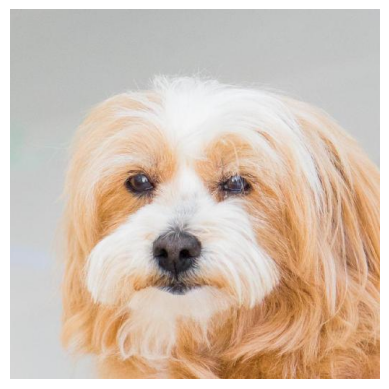

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

raw = Image.open(path).convert("RGB")
plt.imshow(raw)
plt.axis("off")
plt.show()

shape: torch.Size([3, 64, 64])
min/max: 0.03921568766236305 0.9411764740943909


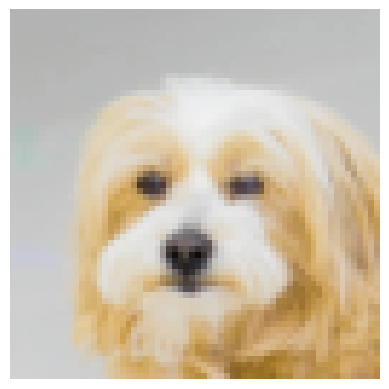

In [8]:
img, label = dataset[0]
print("shape:", img.shape)
print("min/max:", img.min().item(), img.max().item())

plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.show()

batch shape: torch.Size([32, 3, 64, 64])
batch min/max: 0.0 1.0


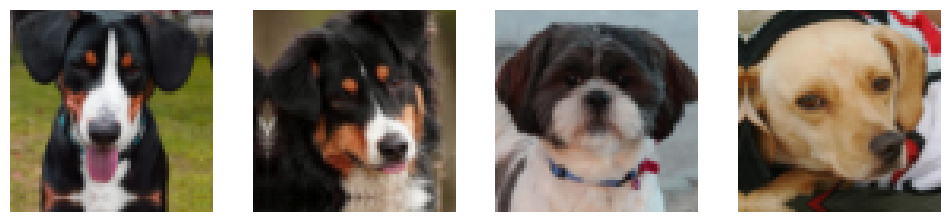

In [9]:
x_batch, _ = next(iter(dataloader))
print("batch shape:", x_batch.shape)
print("batch min/max:", x_batch.min().item(), x_batch.max().item())

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(x_batch[i].permute(1, 2, 0))
    axes[i].axis("off")
plt.show()

## Architecture — Iteration 4 (4-Stage Encoder + Stronger Decoder)

**Key change from Iteration 3:** encoder now has a proper 4th downsampling stage (8×8 → 4×4) before global pooling, matching the original design intent.

Conv(3→64, s=2) + ResBlock(64) fc(32→80×4×4)
[64×32×32] 2× ResBlock(80) [80×4×4]

Conv(64→128, s=2) + ResBlock(128) Upsample+Conv(80→128)
[128×16×16] 2× ResBlock(128) [128×8×8]

Conv(128→256, s=2) + ResBlock(256) Upsample+Conv(128→128)
[256×8×8] 2× ResBlock(128) [128×16×16]

Conv(256→256, s=2) + ResBlock(256) ← NEW Upsample+Conv(128→96)
[256×4×4] 2× ResBlock(96) [96×32×32]

AdaptiveAvgPool → fc_mu / fc_logvar Upsample+Conv(96→64)
z ∈ ℝ³² 2× ResBlock(64) → Conv(64→3) → Sigmoid

- L1 reconstruction loss, β-warmup (8 epochs), AdamW + CosineAnnealingLR
- Screening run: **40 epochs** — full run uses 150

In [10]:
class ResBlock(nn.Module):
    """Basic residual block with optional 1×1 projection on the skip path."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.skip  = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x))

In [11]:
class SelfAttention2d(nn.Module):
    """Spatial self-attention for feature maps — captures long-range structure."""
    def __init__(self, in_ch):
        super().__init__()
        self.norm  = nn.GroupNorm(8, in_ch)
        self.q     = nn.Conv2d(in_ch, in_ch // 4, 1, bias=False)
        self.k     = nn.Conv2d(in_ch, in_ch // 4, 1, bias=False)
        self.v     = nn.Conv2d(in_ch, in_ch,       1, bias=False)
        self.proj  = nn.Conv2d(in_ch, in_ch,       1, bias=False)
        self.scale = (in_ch // 4) ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h    = self.norm(x)
        q    = self.q(h).view(B, -1, H * W)
        k    = self.k(h).view(B, -1, H * W)
        v    = self.v(h).view(B,  C, H * W)
        attn = torch.softmax(q.transpose(1, 2) @ k * self.scale, dim=-1)
        out  = (v @ attn.transpose(1, 2)).view(B, C, H, W)
        return x + self.proj(out)

In [12]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=32, base_ch=64):
        super().__init__()
        C = base_ch
        self.net = nn.Sequential(
            # ── Stage 1: S → S/2 ─────────────────────────────────────────
            nn.Conv2d(3, C, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(C), nn.ReLU(inplace=True),
            ResBlock(C, C),
            # ── Stage 2: S/2 → S/4 ───────────────────────────────────────
            nn.Conv2d(C, C * 2, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(C * 2), nn.ReLU(inplace=True),
            ResBlock(C * 2, C * 2),
            # ── Stage 3: S/4 → S/8 ───────────────────────────────────────
            nn.Conv2d(C * 2, C * 4, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(C * 4), nn.ReLU(inplace=True),
            ResBlock(C * 4, C * 4),
            SelfAttention2d(C * 4),
            # ── Stage 4: S/8 → S/16 (8×8 → 4×4) ─────────────────────────
            nn.Conv2d(C * 4, C * 4, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(C * 4), nn.ReLU(inplace=True),
            ResBlock(C * 4, C * 4),
            # ── Global pooling → 1×1 ─────────────────────────────────────
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc_mu     = nn.Linear(C * 4, latent_dim)
        self.fc_logvar = nn.Linear(C * 4, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

In [13]:
class StrongerDecoder(nn.Module):
    """Decoder with Upsample+Conv (no checkerboard), 2 ResBlocks/stage, wider channels."""

    def __init__(self, latent_dim: int, dec_start_ch: int = 80, img_size: int = 64):
        super().__init__()
        dc = dec_start_ch  # e.g. 80

        self.fc = nn.Linear(latent_dim, dc * 4 * 4)

        # ── stage 4×4 ──────────────────────────────────────────────────────
        self.res4 = nn.Sequential(ResBlock(dc, dc), ResBlock(dc, dc))

        # ── 4→8 ────────────────────────────────────────────────────────────
        self.up1 = self._up_block(dc, 128)
        self.res8 = nn.Sequential(ResBlock(128, 128), ResBlock(128, 128))

        # ── 8→16 ───────────────────────────────────────────────────────────
        self.up2 = self._up_block(128, 128)
        self.res16 = nn.Sequential(ResBlock(128, 128), ResBlock(128, 128))

        # ── 16→32 ──────────────────────────────────────────────────────────
        self.up3 = self._up_block(128, 96)
        self.res32 = nn.Sequential(ResBlock(96, 96), ResBlock(96, 96))

        # ── 32→64 ──────────────────────────────────────────────────────────
        self.up4 = self._up_block(96, 64)
        self.res64 = nn.Sequential(ResBlock(64, 64), ResBlock(64, 64))

        # ── output ─────────────────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=1),
            nn.Sigmoid(),
        )

        self.dc = dc

    @staticmethod
    def _up_block(in_ch: int, out_ch: int) -> nn.Sequential:
        """2× nearest-neighbour upsample followed by a 3×3 conv block."""
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.fc(z).view(-1, self.dc, 4, 4)
        x = self.res4(x)
        x = self.res8(self.up1(x))
        x = self.res16(self.up2(x))
        x = self.res32(self.up3(x))
        x = self.res64(self.up4(x))
        return self.head(x)


print("StrongerDecoder defined.")


StrongerDecoder defined.


In [14]:
class VAE(nn.Module):
    def __init__(
        self,
        latent_dim: int = 32,
        base_channels: int = 64,
        dec_start_ch: int = 80,
        img_size: int = 64,
    ):
        super().__init__()
        self.encoder = Encoder(latent_dim=latent_dim, base_ch=base_channels)
        self.decoder = StrongerDecoder(latent_dim, dec_start_ch, img_size)

    def reparameterise(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu  # deterministic at eval time

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

    def sample(self, n: int, device: torch.device) -> torch.Tensor:
        z = torch.randn(n, self.encoder.fc_mu.out_features, device=device)
        return self.decode(z)


print("VAE class defined.")


VAE class defined.


In [15]:
set_seed(CFG["seed"])

vae = VAE(
    latent_dim=CFG["latent_dim"],
    base_channels=CFG["base_channels"],
    dec_start_ch=CFG["dec_start_ch"],
    img_size=CFG["image_size"],
).to(DEVICE)

total_params = sum(p.numel() for p in vae.parameters())
trainable_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
assert total_params <= 26_000_000, f"Model too large: {total_params:,} > 26M"
print(f"Model device: {next(vae.parameters()).device}")


Random seed set to: 42
Total params:     7,402,435
Trainable params: 7,402,435
Model device: cuda:0


## Loss Function & Optimizer

- **Reconstruction loss**: MSE (sum, normalised by batch size) — swap for `l1` or `bce` via `CFG["recon_loss_type"]`
- **KL divergence**: standard ELBO term, weighted by β
- **β-annealing**: β rises linearly 0 → `beta_max` over `kl_warmup_epochs` to prevent posterior collapse in early training
- **Optimizer**: AdamW with weight decay
- **Scheduler**: CosineAnnealingLR
- **AMP**: GradScaler for mixed-precision training (GPU only)

In [16]:
def recon_loss_fn(recon_x, x, loss_type="mse"):
    if loss_type == "mse":
        return F.mse_loss(recon_x, x, reduction="sum")
    elif loss_type == "l1":
        return F.l1_loss(recon_x, x, reduction="sum")
    elif loss_type == "bce":
        return F.binary_cross_entropy(recon_x, x, reduction="sum")
    raise ValueError(f"Unknown loss type: {loss_type}")


def vae_loss(recon_x, x, mu, logvar, beta=1.0, loss_type="mse"):
    recon = recon_loss_fn(recon_x, x, loss_type) / x.size(0)
    kl    = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)
    return recon + beta * kl, recon.item(), kl.item()


optimizer = optim.AdamW(vae.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["num_epochs"])
scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

print("Loss, optimizer, and scheduler ready.")

Loss, optimizer, and scheduler ready.


C:\Users\josep\AppData\Local\Temp\ipykernel_39640\2321000679.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


## Training Loop

Tracks per-epoch: total loss, reconstruction loss, KL divergence, β, and learning rate.  
Saves the best checkpoint (lowest total loss) to `CFG["checkpoint_dir"]/best.pth`.

In [17]:
torch.cuda.empty_cache()  # clear any stale GPU allocations from previous runs
history   = {"total": [], "recon": [], "kl": [], "beta": [], "lr": []}
best_loss = float("inf")

for epoch in range(1, CFG["num_epochs"] + 1):

    # ── KL warmup: β rises linearly 0 → beta_max ─────────────────────────
    beta = min(CFG["beta_max"],
               CFG["beta_max"] * epoch / max(CFG["kl_warmup_epochs"], 1))

    vae.train()
    epoch_total = epoch_recon = epoch_kl = 0.0

    for x, _ in dataloader:
        x = x.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            recon_x, mu, logvar = vae(x)
            loss, r, k = vae_loss(recon_x, x, mu, logvar,
                                  beta=beta,
                                  loss_type=CFG["recon_loss_type"])

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(vae.parameters(), CFG["grad_clip"])
        scaler.step(optimizer)
        scaler.update()

        epoch_total += loss.item()
        epoch_recon += r
        epoch_kl    += k

    scheduler.step()

    n = len(dataloader)
    history["total"].append(epoch_total / n)
    history["recon"].append(epoch_recon / n)
    history["kl"].append(epoch_kl    / n)
    history["beta"].append(beta)
    history["lr"].append(scheduler.get_last_lr()[0])

    # ── Save best checkpoint ──────────────────────────────────────────────
    if history["total"][-1] < best_loss:
        best_loss = history["total"][-1]
        torch.save(vae.state_dict(),
                   os.path.join(CFG["checkpoint_dir"], "best.pth"))

    # ── Print every 10 epochs ─────────────────────────────────────────────
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>4}/{CFG['num_epochs']}  "
              f"loss={history['total'][-1]:.4f}  "
              f"recon={history['recon'][-1]:.4f}  "
              f"kl={history['kl'][-1]:.4f}  "
              f"β={beta:.3f}  "
              f"lr={history['lr'][-1]:.2e}")

print(f"\nTraining complete. Best loss: {best_loss:.4f}")

C:\Users\josep\AppData\Local\Temp\ipykernel_39640\3079672862.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch    1/250  loss=2279.9856  recon=2273.5279  kl=51.6614  β=0.125  lr=1.00e-03
Epoch   10/250  loss=1535.4236  recon=1481.4346  kl=53.9889  β=1.000  lr=9.96e-04
Epoch   20/250  loss=1380.4394  recon=1320.3794  kl=60.0600  β=1.000  lr=9.84e-04
Epoch   30/250  loss=1301.7052  recon=1235.8962  kl=65.8090  β=1.000  lr=9.65e-04
Epoch   40/250  loss=1248.7385  recon=1179.7598  kl=68.9787  β=1.000  lr=9.38e-04
Epoch   50/250  loss=1212.2089  recon=1141.1709  kl=71.0380  β=1.000  lr=9.05e-04
Epoch   60/250  loss=1187.8824  recon=1116.0644  kl=71.8179  β=1.000  lr=8.64e-04
Epoch   70/250  loss=1166.1083  recon=1093.0552  kl=73.0531  β=1.000  lr=8.19e-04
Epoch   80/250  loss=1151.0375  recon=1077.3120  kl=73.7255  β=1.000  lr=7.68e-04
Epoch   90/250  loss=1137.1805  recon=1063.1479  kl=74.0326  β=1.000  lr=7.13e-04
Epoch  100/250  loss=1119.7023  recon=1045.1813  kl=74.5210  β=1.000  lr=6.55e-04
Epoch  110/250  loss=1111.2689  recon=1035.7716  kl=75.4973  β=1.000  lr=5.94e-04
Epoch  120/250  

## Training Curves & Visual Diagnostics

Four plots:
1. **Total loss** — overall ELBO objective per epoch
2. **Reconstruction loss** — how well the decoder reproduces inputs
3. **KL divergence** — regularisation strength (should grow after warmup)
4. **β schedule + Learning rate** — confirm warmup and cosine decay are behaving

Then two visual checks:
- **Reconstruction grid** — real images (top) vs. decoder reconstructions (bottom)
- **Generated samples grid** — 64 random latent vectors decoded
- **Latent interpolation** — smooth walk between two encoded dog faces

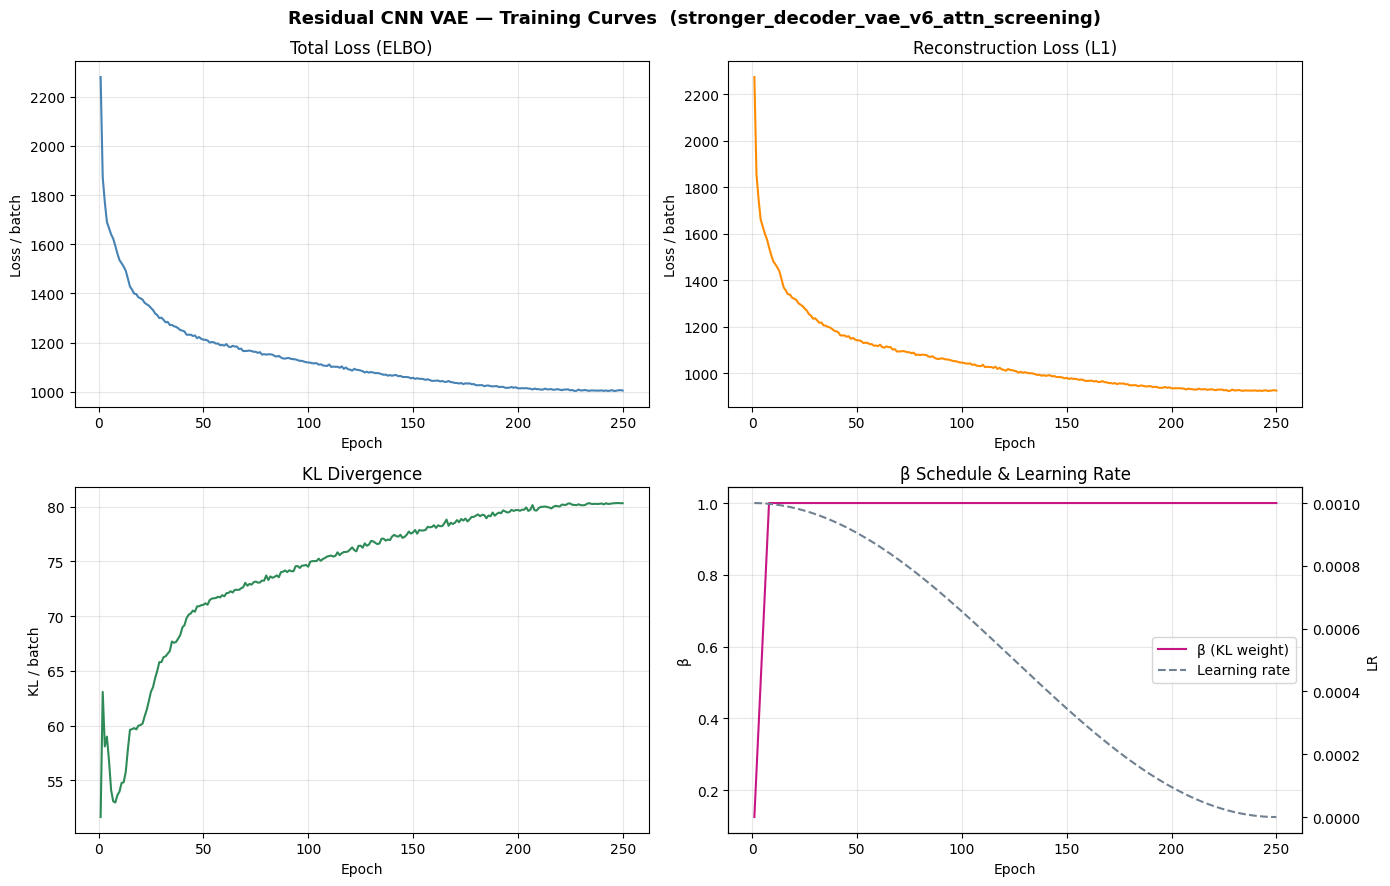

Saved → ./Iteration11/checkpoints/stronger_decoder/training_curves.png


In [18]:
def plot_training_curves(history):
    epochs = range(1, len(history["total"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"Residual CNN VAE — Training Curves  ({CFG['experiment_name']})",
                 fontsize=13, fontweight="bold")

    # ── Total loss ────────────────────────────────────────────────────────
    axes[0, 0].plot(epochs, history["total"], color="steelblue", linewidth=1.5)
    axes[0, 0].set_title("Total Loss (ELBO)")
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss / batch")
    axes[0, 0].grid(True, alpha=0.3)

    # ── Reconstruction loss ───────────────────────────────────────────────
    axes[0, 1].plot(epochs, history["recon"], color="darkorange", linewidth=1.5)
    axes[0, 1].set_title(f"Reconstruction Loss ({CFG['recon_loss_type'].upper()})")
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss / batch")
    axes[0, 1].grid(True, alpha=0.3)

    # ── KL divergence ─────────────────────────────────────────────────────
    axes[1, 0].plot(epochs, history["kl"], color="seagreen", linewidth=1.5)
    axes[1, 0].set_title("KL Divergence")
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("KL / batch")
    axes[1, 0].grid(True, alpha=0.3)

    # ── β schedule + LR on twin axes ──────────────────────────────────────
    ax_beta = axes[1, 1]
    ax_lr   = ax_beta.twinx()
    l1, = ax_beta.plot(epochs, history["beta"], color="mediumvioletred",
                       linewidth=1.5, label="β (KL weight)")
    l2, = ax_lr.plot(epochs, history["lr"],   color="slategray",
                     linewidth=1.5, linestyle="--", label="Learning rate")
    ax_beta.set_title("β Schedule & Learning Rate")
    ax_beta.set_xlabel("Epoch")
    ax_beta.set_ylabel("β"); ax_lr.set_ylabel("LR")
    ax_beta.legend(handles=[l1, l2], loc="center right")
    ax_beta.grid(True, alpha=0.3)

    plt.tight_layout()
    out = os.path.join(CFG["checkpoint_dir"], "training_curves.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Saved → {out}")


plot_training_curves(history)

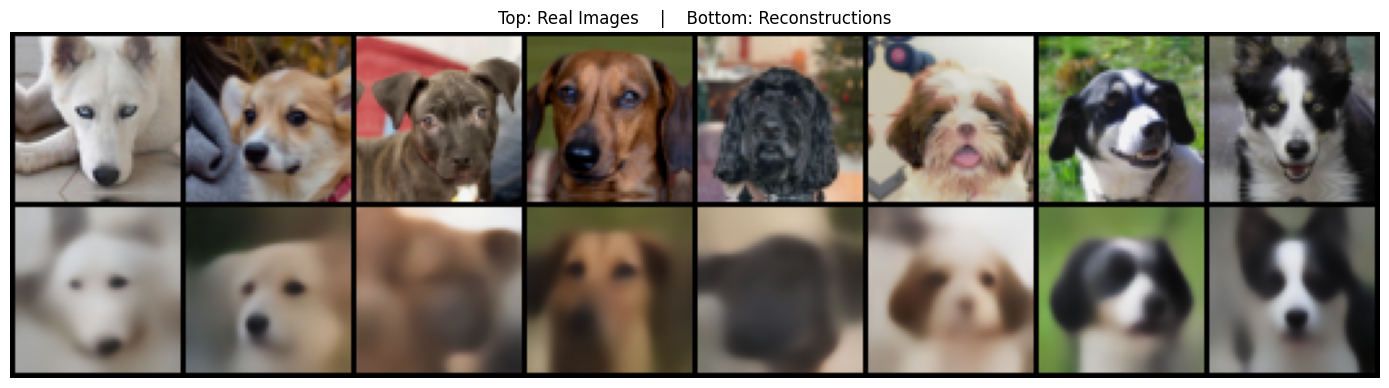

Saved → ./Iteration11/checkpoints/stronger_decoder/reconstructions.png


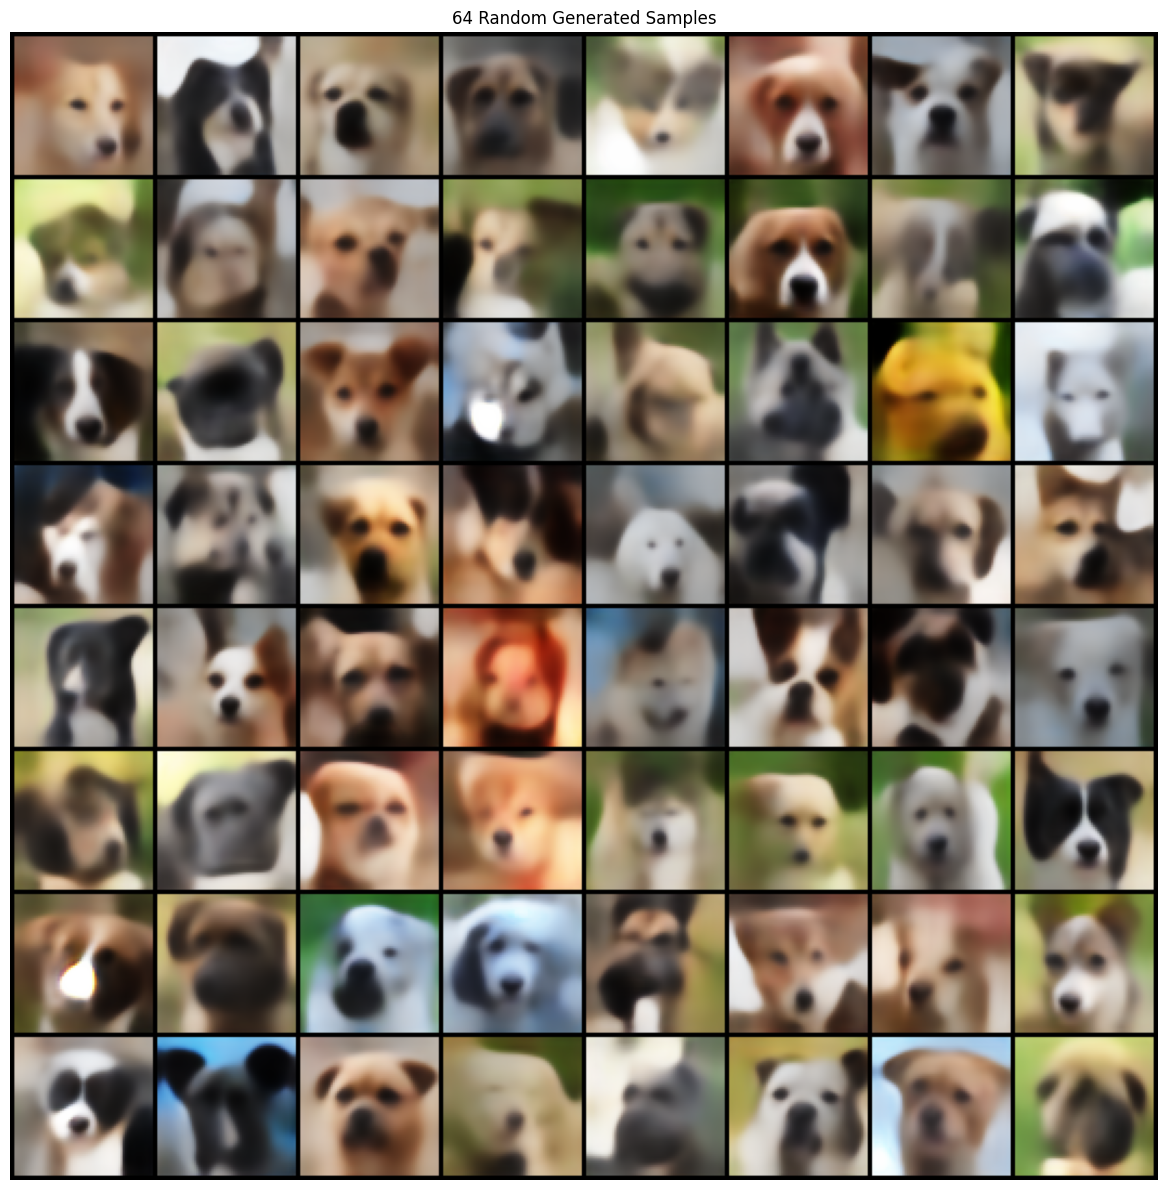

Saved → ./Iteration11/checkpoints/stronger_decoder/generated_samples.png


In [19]:
def plot_reconstructions(vae, dataloader, device, n=8):
    vae = vae.to(device)
    vae.eval()

    x_batch, _ = next(iter(dataloader))
    x_batch = x_batch[:n].to(device)

    with torch.no_grad():
        recon, _, _ = vae(x_batch)

    real = x_batch.detach().cpu()
    recon = recon.detach().cpu()

    comparison = torch.cat([real, recon], dim=0)
    grid = vutils.make_grid(comparison, nrow=n, normalize=False, padding=2)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.axis("off")
    ax.set_title("Top: Real Images    |    Bottom: Reconstructions", fontsize=12)
    plt.tight_layout()
    out = os.path.join(CFG["checkpoint_dir"], "reconstructions.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Saved → {out}")


def plot_generated_samples(vae, device, n=64):
    vae = vae.to(device)
    vae.eval()
    with torch.no_grad():
        z = torch.randn(n, CFG["latent_dim"]).to(device)
        samples = vae.decode(z).detach().cpu()

    grid = vutils.make_grid(samples, nrow=8, normalize=False, padding=2)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.axis("off")
    ax.set_title(f"{n} Random Generated Samples", fontsize=12)
    plt.tight_layout()
    out = os.path.join(CFG["checkpoint_dir"], "generated_samples.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Saved → {out}")


plot_reconstructions(vae, dataloader, device)
plot_generated_samples(vae, device)

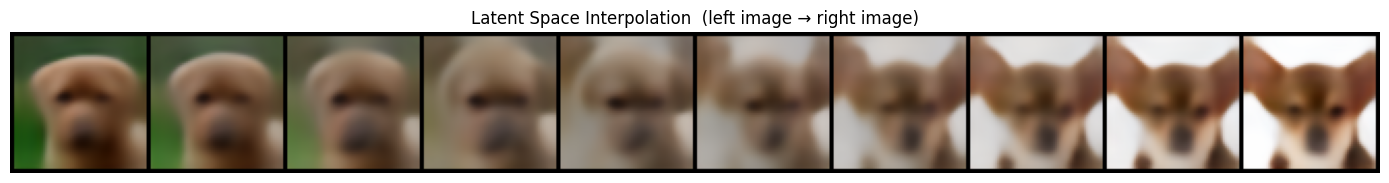

Saved → ./Iteration11/checkpoints/stronger_decoder/latent_interpolation.png


In [20]:
def plot_latent_interpolation(vae, dataloader, device, steps=10):
    """Linearly interpolate in latent space between two real images."""
    vae.eval()
    x_batch, _ = next(iter(dataloader))
    x1 = x_batch[0:1].to(device)
    x2 = x_batch[1:2].to(device)

    with torch.no_grad():
        mu1, _ = vae.encoder(x1)
        mu2, _ = vae.encoder(x2)
        alphas = torch.linspace(0, 1, steps).to(device)
        frames = torch.cat([vae.decode((1 - a) * mu1 + a * mu2) for a in alphas], dim=0)

    grid = vutils.make_grid(frames.cpu(), nrow=steps, normalize=True, padding=2)
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.imshow(grid.permute(1, 2, 0).numpy().clip(0, 1))
    ax.axis("off")
    ax.set_title("Latent Space Interpolation  (left image → right image)", fontsize=12)
    plt.tight_layout()
    out = os.path.join(CFG["checkpoint_dir"], "latent_interpolation.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Saved → {out}")


plot_latent_interpolation(vae, dataloader, device)

## Evaluation & Submission

The evaluation cell below is **unchanged from the provided test function**.  
It loads the best checkpoint, generates 5,000 images, and computes FID, IS, and GMS.

In [21]:
# ── Load best checkpoint ──────────────────────────────────────────────────
vae.load_state_dict(torch.load(os.path.join(CFG["checkpoint_dir"], "best.pth"),
                                map_location=device))
vae.eval()
print("Best checkpoint loaded.")

# ── Generate 5000 images in chunks to avoid OOM ─────────────────────────
save_dir = CFG["save_dir_images"]
os.makedirs(save_dir, exist_ok=True)

chunk_size = 200
n_total    = 5000
img_idx    = 0
vae.eval()
with torch.no_grad():
    for _ in range(n_total // chunk_size):
        z = torch.randn(chunk_size, CFG["latent_dim"]).to(device)
        imgs = vae.decode(z)
        imgs = (imgs * 255).clamp(0, 255).to(torch.uint8).float() / 255.0
        for img in imgs:
            vutils.save_image(img, f"{save_dir}image_{img_idx}.jpg")
            img_idx += 1
        del z, imgs
        torch.cuda.empty_cache()

if img_idx == 0:
    raise ValueError("No generated images were saved!")

# ── Free GPU memory before torch_fidelity loads InceptionV3 ──────────────
vae.cpu()
torch.cuda.empty_cache()

# ── Resolve absolute paths so torch_fidelity is not affected by cwd ───────
input1_path = os.path.abspath(save_dir)
input2_path = os.path.abspath(CFG["real_images_dir"])
print(f"input1 : {input1_path}  (exists={os.path.isdir(input1_path)})")
print(f"input2 : {input2_path}  (exists={os.path.isdir(input2_path)})")

# ── Compute metrics (DO NOT MODIFY) ──────────────────────────────────────
metrics = torch_fidelity.calculate_metrics(
    input1 = input1_path,
    input2 = input2_path,
    cuda   = torch.cuda.is_available(),
    fid    = True,
    isc    = True,
)

fid_score = metrics["frechet_inception_distance"]
is_score  = metrics["inception_score_mean"]
is_std    = metrics["inception_score_std"]

if is_score > 0:
    s_value = np.sqrt(fid_score / is_score)
    print(f"FID : {fid_score:.4f}")
    print(f"IS  : {is_score:.4f}  (std={is_std:.4f})")
    print(f"GMS : {s_value:.5f}")
else:
    print("IS is 0 — GMS cannot be computed!")


C:\Users\josep\AppData\Local\Temp\ipykernel_39640\516151086.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load(os.path.join(CFG["checkpoint_d

Best checkpoint loaded.
input1 : c:\Users\josep\Y3S2\CS424\Assgin2\cs-424-assign-2-friday\Iteration11\generated_images  (exists=True)
input2 : c:\Users\josep\Y3S2\CS424\Assgin2\cs-424-assign-2-friday\VAE_generation\train  (exists=True)


Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']
Extracting features from input1
Looking for samples non-recursivelty in "c:\Users\josep\Y3S2\CS424\Assgin2\cs-424-assign-2-friday\Iteration11\generated_images" with extensions png,jpg,jpeg
Found 5000 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                           
Extracting features from input2
Looking for samples non-recursivelty in "c:\Users\josep\Y3S2\CS424\Assgin2\cs-424-assign-2-friday\VAE_generation\train" with extensions png,jpg,jpeg
Found 5000 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                           
Inception Score: 4.766158 ± 0.1344514


FID : 150.0855
IS  : 4.7662  (std=0.1345)
GMS : 5.61158


Frechet Inception Distance: 150.0855


In [22]:
log = {
    "student_id":    "01442523",
    "experiment":    CFG["experiment_name"],
    "architecture":  "Stronger Decoder VAE",
    "latent_dim":    CFG["latent_dim"],
    "base_channels": CFG["base_channels"],
    "dec_start_ch":  CFG["dec_start_ch"],
    "total_params":  total_params,
    "num_epochs":    CFG["num_epochs"],
    "batch_size":    CFG["batch_size"],
    "lr":            CFG["lr"],
    "beta_max":      CFG["beta_max"],
    "kl_warmup":     CFG["kl_warmup_epochs"],
    "recon_loss":    CFG["recon_loss_type"],
    "FID":           round(float(fid_score), 4),
    "IS_mean":       round(float(is_score), 4),
    "IS_std":        round(float(is_std), 4),
    "GMS":           round(float(s_value), 4),
    "device":        str(DEVICE),
    "notes":         "2 ResBlocks/stage, Upsample+Conv decoder, dec_start_ch=80, wider mid-level channels",
}

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = f"{CFG['experiment_name']}_{timestamp}.csv"
pd.DataFrame([log]).to_csv(csv_path, index=False)
print(f"Results saved → {csv_path}")
print(pd.DataFrame([log]).T.to_string())


Results saved → stronger_decoder_vae_v6_attn_screening_20260312_131937.csv
                                                                                                 0
student_id                                                                                01442523
experiment                                                  stronger_decoder_vae_v6_attn_screening
architecture                                                                  Stronger Decoder VAE
latent_dim                                                                                      32
base_channels                                                                                   64
dec_start_ch                                                                                   128
total_params                                                                               7402435
num_epochs                                                                                     250
batch_size                        